# Weeks 13–14: Artificial Neural Networks

**Goal:** Implement a multi-layer perceptron from scratch in MiniLearn.  Apply at least one off-the-shelf deep learning model (Dense NN, 1D-CNN, or LSTM).  Compare neural networks to the best classical models.  Finalize the report.

**Deliverable:** `minilearn/ann.py` (MLP complete) + DL notebook + cleaned final report.

---
## Checklist
- [ ] `MLP` in MiniLearn — forward pass, backprop, mini-batch SGD, loss curve
- [ ] Off-the-shelf model in TensorFlow/Keras or PyTorch (Dense NN minimum; 1D-CNN or LSTM for bonus)
- [ ] Training/validation loss and accuracy curves
- [ ] Full metrics (accuracy, F1, confusion matrix, AUC) for all DL models
- [ ] Final model comparison table (all methods)
- [ ] Written conclusion

In [1]:
import os
import sys
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

from minilearn.ann import MLP
from minilearn.metrics import accuracy, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

OUTPUT_DIR = 'C:\\Users\\Grana\\Documents\\GitHub\\Project_CSE432_MG\\Project_CSE432-532\\SER_Project\\output'

EMOTION_MAP = {
    1: 'neutral', 2: 'calm',    3: 'happy',    4: 'sad',
    5: 'angry',   6: 'fearful', 7: 'disgust',  8: 'surprised'
}
emotion_labels = [EMOTION_MAP[i] for i in sorted(EMOTION_MAP)]
N_CLASSES = 8

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

X_train = np.load(os.path.join(OUTPUT_DIR, 'X_train.npy'))
X_test  = np.load(os.path.join(OUTPUT_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(OUTPUT_DIR, 'y_train.npy')).astype(int)
y_test  = np.load(os.path.join(OUTPUT_DIR, 'y_test.npy')).astype(int)

# PyTorch expects 0-based integer labels
y_train_0 = y_train - 1
y_test_0  = y_test  - 1

print(f'X_train : {X_train.shape}   X_test : {X_test.shape}')
print(f'PyTorch version : {torch.__version__}')


X_train : (1956, 112)   X_test : (496, 112)
PyTorch version : 2.9.1+cu130


## 1. MiniLearn MLP

MiniLearn MLP — Test Accuracy : 0.4335   Macro-F1 : 0.3647
Training time : 2.1s


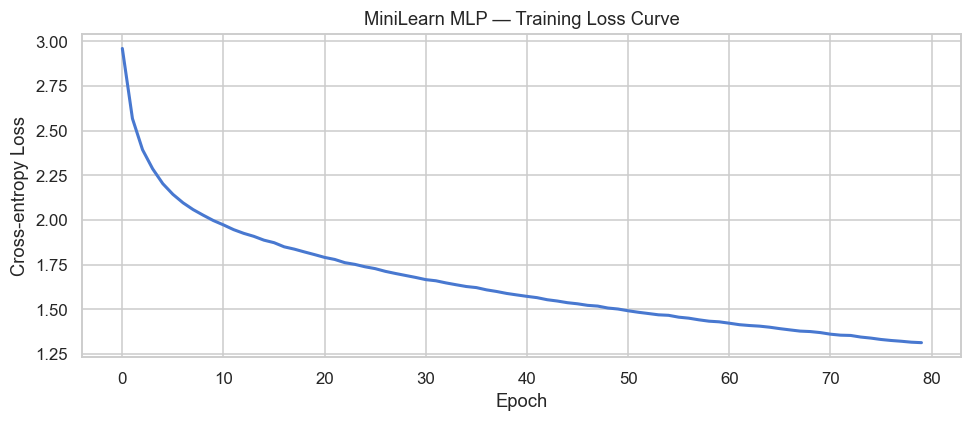

In [2]:
n_features = X_train.shape[1]

mlp = MLP(
    layer_sizes=[n_features, 256, 128, 64, N_CLASSES],
    activation='relu',
    lr=0.001,
    n_epochs=80,
    batch_size=64,
    l2_lambda=1e-4,
    random_state=42,
)

t0 = time.time()
mlp.fit(X_train, y_train)
ml_train_time = time.time() - t0

y_pred_mlp = mlp.predict(X_test)
ml_acc = accuracy(y_test, y_pred_mlp)
ml_f1  = f1_score(y_test, y_pred_mlp, average='macro')

print(f'MiniLearn MLP — Test Accuracy : {ml_acc:.4f}   Macro-F1 : {ml_f1:.4f}')
print(f'Training time : {ml_train_time:.1f}s')

# ── Loss curve ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mlp.loss_history_, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-entropy Loss')
ax.set_title('MiniLearn MLP — Training Loss Curve')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mlp_loss_curve.png'), bbox_inches='tight')
plt.show()

## 2. Off-the-Shelf Deep Learning Model

Use TensorFlow/Keras or PyTorch to build a more expressive network.  
Options: Dense NN (required minimum), 1D-CNN (recommended), LSTM (advanced).

Using device: cpu
DenseNN(
  (net): Sequential(
    (0): Linear(in_features=112, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.2, inplace=False)
    (11): Linear(in_features=64, out_features=8, bias=True)
  )
)
Early stopping at epoch 34
Training time : 2.2s   Epochs run : 34


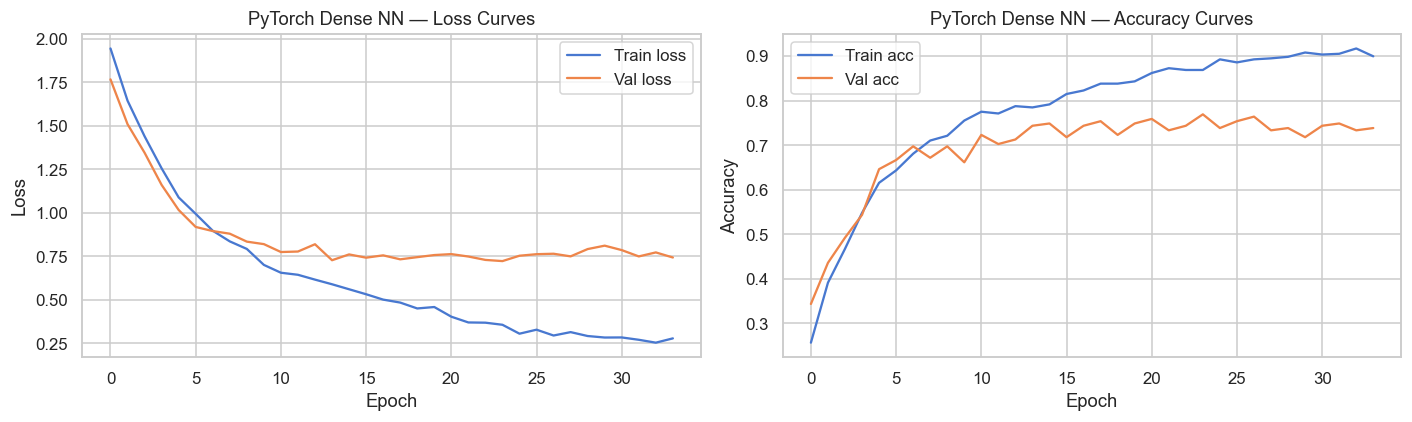


PyTorch Dense NN — Test Accuracy : 0.7520   Macro-F1 : 0.7407


In [3]:
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

n_features = X_train.shape[1]

# ── Dense NN architecture ─────────────────────────────────────────────────────
class DenseNN(nn.Module):
    def __init__(self, input_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, n_classes),
        )
    def forward(self, x):
        return self.net(x)

# ── Validation split (10%) ────────────────────────────────────────────────────
rng_split = np.random.default_rng(42)
perm      = rng_split.permutation(len(X_train))
n_val     = int(len(X_train) * 0.1)
tr_idx, val_idx = perm[n_val:], perm[:n_val]

X_tr_t  = torch.tensor(X_train[tr_idx],   dtype=torch.float32)
y_tr_t  = torch.tensor(y_train_0[tr_idx], dtype=torch.long)
X_val_t = torch.tensor(X_train[val_idx],  dtype=torch.float32)
y_val_t = torch.tensor(y_train_0[val_idx], dtype=torch.long)
X_tst_t = torch.tensor(X_test,            dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True)

torch_model = DenseNN(n_features, N_CLASSES).to(device)
print(torch_model)

optimizer = optim.Adam(torch_model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5, min_lr=1e-6)
criterion = nn.CrossEntropyLoss()

# ── Training loop with early stopping ─────────────────────────────────────────
train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_loss, best_state, patience_cnt = float('inf'), None, 0
PATIENCE, MAX_EPOCHS = 10, 100

t0 = time.time()
for epoch in range(1, MAX_EPOCHS + 1):
    torch_model.train()
    ep_loss, ep_correct = 0.0, 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = torch_model(Xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        ep_loss    += loss.item() * len(yb)
        ep_correct += (logits.argmax(1) == yb).sum().item()

    tr_loss = ep_loss / len(y_tr_t)
    tr_acc  = ep_correct / len(y_tr_t)

    torch_model.eval()
    with torch.no_grad():
        val_logits = torch_model(X_val_t.to(device))
        vl_loss = criterion(val_logits, y_val_t.to(device)).item()
        vl_acc  = (val_logits.argmax(1) == y_val_t.to(device)).float().mean().item()

    train_losses.append(tr_loss); val_losses.append(vl_loss)
    train_accs.append(tr_acc);    val_accs.append(vl_acc)
    scheduler.step(vl_loss)

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_state    = {k: v.cpu().clone() for k, v in torch_model.state_dict().items()}
        patience_cnt  = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

keras_train_time = time.time() - t0
print(f'Training time : {keras_train_time:.1f}s   Epochs run : {epoch}')

# Restore best weights
torch_model.load_state_dict(best_state)

# ── Training / validation curves ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(train_losses, label='Train loss')
axes[0].plot(val_losses,   label='Val loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('PyTorch Dense NN — Loss Curves'); axes[0].legend()

axes[1].plot(train_accs, label='Train acc')
axes[1].plot(val_accs,   label='Val acc')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('PyTorch Dense NN — Accuracy Curves'); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'keras_training_curves.png'), bbox_inches='tight')
plt.show()

# ── Test evaluation ───────────────────────────────────────────────────────────
torch_model.eval()
with torch.no_grad():
    logits_test  = torch_model(X_tst_t.to(device))
    keras_prob_np = torch.softmax(logits_test, dim=1).cpu().numpy()  # shape (n_test, 8)

y_pred_keras_0 = np.argmax(keras_prob_np, axis=1)
y_pred_keras   = y_pred_keras_0 + 1    # map back to 1-8

keras_acc = accuracy(y_test, y_pred_keras)
keras_f1  = f1_score(y_test, y_pred_keras, average='macro')
print(f'\nPyTorch Dense NN — Test Accuracy : {keras_acc:.4f}   Macro-F1 : {keras_f1:.4f}')


## 3. Confusion Matrix & Per-Class Analysis

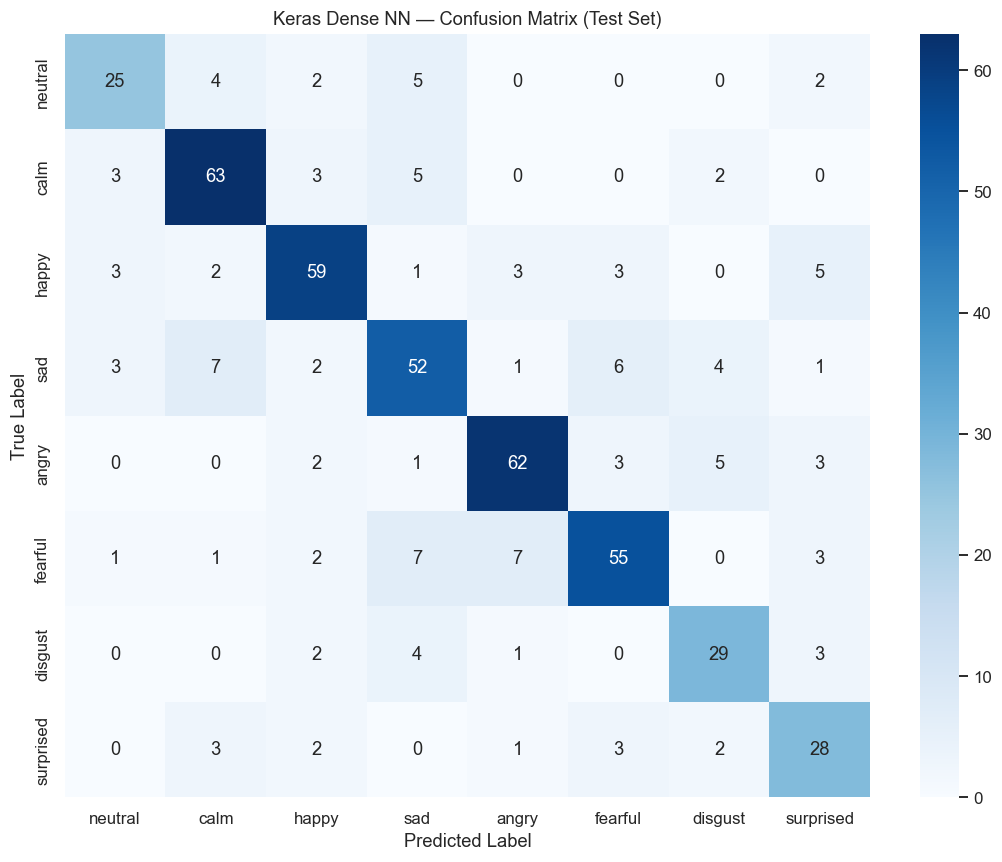

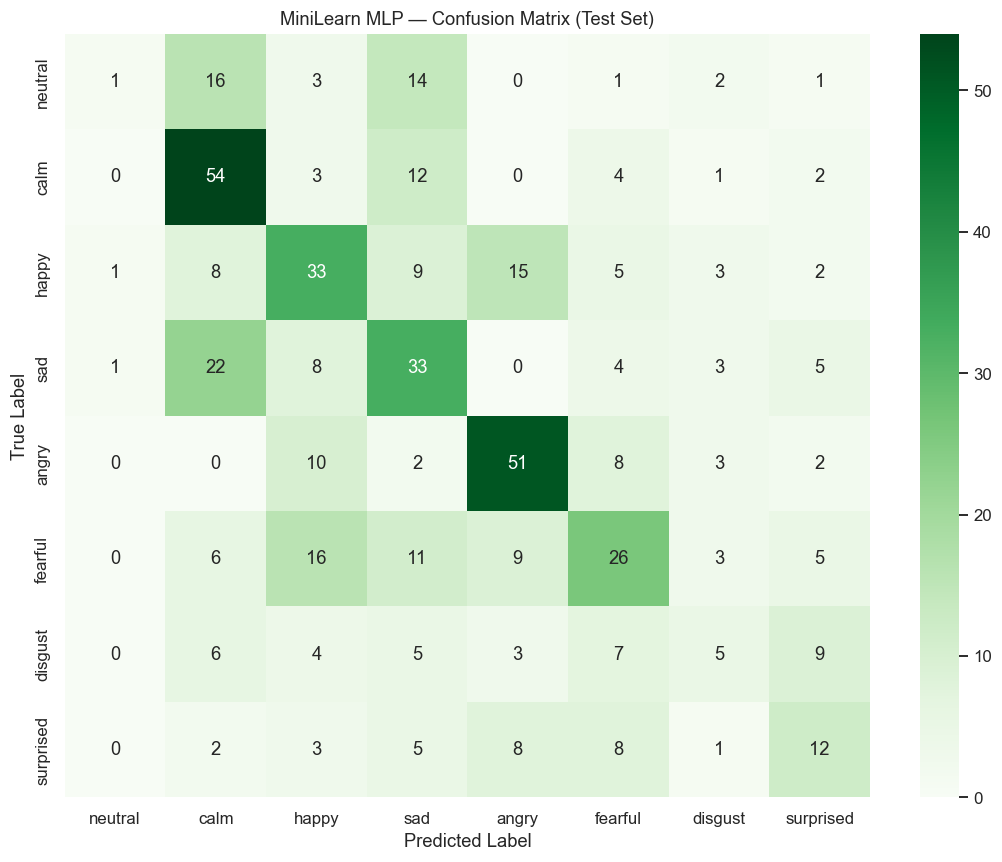

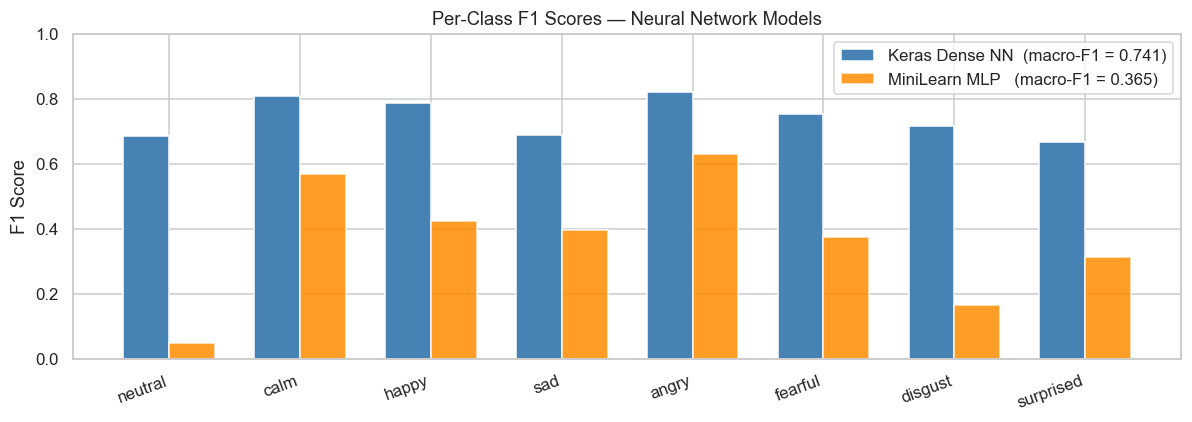


Emotion        Keras F1  MiniLearn F1
-------------------------------------
neutral          0.6849        0.0488
calm             0.8077        0.5684
happy            0.7867        0.4231
sad              0.6887        0.3952
angry            0.8212        0.6296
fearful          0.7534        0.3741
disgust          0.7160        0.1667
surprised        0.6667        0.3117


In [4]:
# ── Confusion matrix — Keras Dense NN (best DL model) ────────────────────────
cm_keras = confusion_matrix(y_test, y_pred_keras)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_keras, annot=True, fmt='d', cmap='Blues',
    xticklabels=emotion_labels, yticklabels=emotion_labels, ax=ax
)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Keras Dense NN — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'keras_confusion_matrix.png'), bbox_inches='tight')
plt.show()

# ── MiniLearn MLP confusion matrix ────────────────────────────────────────────
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_mlp, annot=True, fmt='d', cmap='Greens',
    xticklabels=emotion_labels, yticklabels=emotion_labels, ax=ax
)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('MiniLearn MLP — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mlp_confusion_matrix.png'), bbox_inches='tight')
plt.show()

# ── Per-class F1 scores ────────────────────────────────────────────────────────
from sklearn.metrics import f1_score as sk_f1_pc

labels_ordered = sorted(EMOTION_MAP)  # [1, 2, ..., 8]
keras_pc_f1 = sk_f1_pc(y_test, y_pred_keras, average=None, labels=labels_ordered)
mlp_pc_f1   = sk_f1_pc(y_test, y_pred_mlp,   average=None, labels=labels_ordered)

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(N_CLASSES)
w = 0.35
ax.bar(x - w/2, keras_pc_f1, w, label=f'Keras Dense NN  (macro-F1 = {keras_f1:.3f})', color='steelblue')
ax.bar(x + w/2, mlp_pc_f1,   w, label=f'MiniLearn MLP   (macro-F1 = {ml_f1:.3f})',   color='darkorange', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(emotion_labels, rotation=20, ha='right')
ax.set_ylim(0, 1); ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Scores — Neural Network Models')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'nn_per_class_f1.png'), bbox_inches='tight')
plt.show()

print(f'\n{"Emotion":<12} {"Keras F1":>10} {"MiniLearn F1":>13}')
print('-' * 37)
for emo, kf, mf in zip(emotion_labels, keras_pc_f1, mlp_pc_f1):
    print(f'{emo:<12} {kf:>10.4f} {mf:>13.4f}')


## 4. Final Model Comparison Table

Combine all results from Weeks 7–14 into one comprehensive table.

Fitting Logistic Regression... acc=0.6734
Fitting Gaussian Naive Bayes... acc=0.3750
Fitting KNN (k=11)... acc=0.5060
Fitting SVM (Linear)... acc=0.6391
Fitting SVM (RBF)... acc=0.6734
Fitting Decision Tree... acc=0.3891
Fitting Random Forest... acc=0.6028
Fitting AdaBoost... acc=0.3871

FINAL MODEL COMPARISON — Speech Emotion Recognition (RAVDESS, 8 emotions)
                      CV Acc  Test Acc  Macro-F1     AUC  Train Time (s)
Model                                                                   
Logistic Regression   0.6079    0.6734    0.6693  0.9317             0.1
Gaussian Naive Bayes  0.3635    0.3750    0.3490  0.7845             0.0
KNN (k=11)             0.455    0.5060    0.4731  0.8593             0.0
SVM (Linear)          0.5803    0.6391    0.6288       —             0.1
SVM (RBF)             0.6191    0.6734    0.6644       —             0.1
Decision Tree         0.3763    0.3891    0.3726  0.7327             0.1
Random Forest          0.567    0.6028    0.5863  0.9

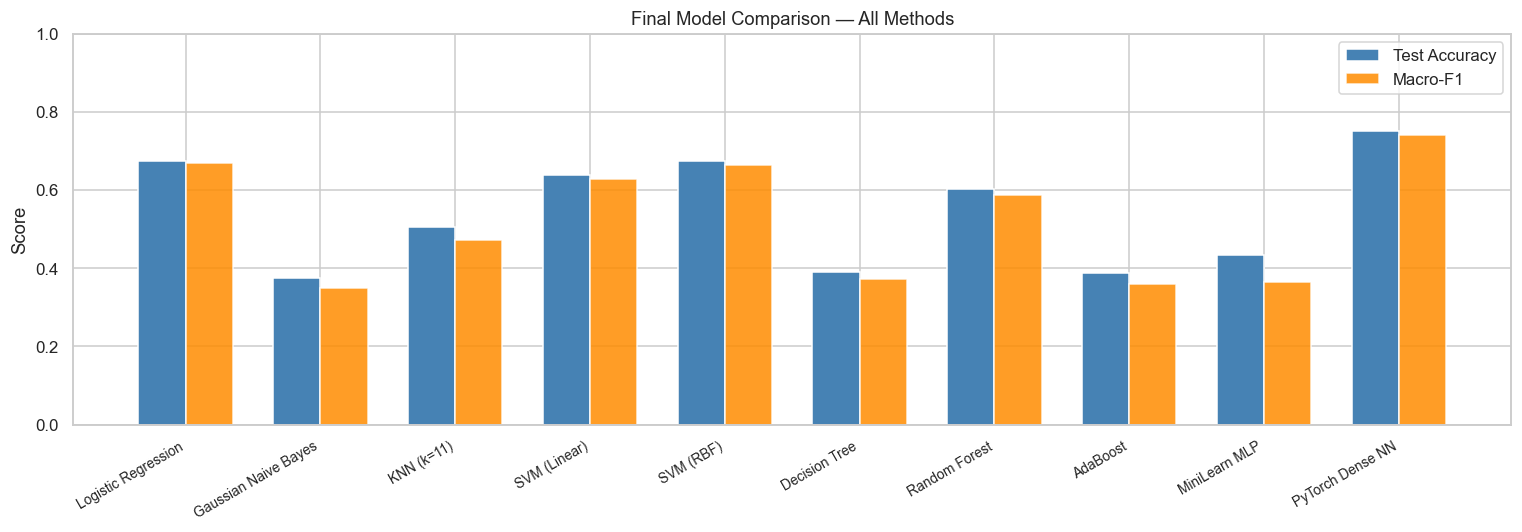

In [5]:
import copy
from sklearn.linear_model import LogisticRegression as SkLR
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import cross_val_score as sk_cv
from sklearn.metrics import roc_auc_score as sk_auc, f1_score as sk_f1_all

LABELS_ORDER = sorted(EMOTION_MAP)  # [1, 2, ..., 8]

classical_models = {
    'Logistic Regression': SkLR(max_iter=1000, solver='lbfgs'),
    'Gaussian Naive Bayes': GaussianNB(),
    'KNN (k=11)': KNeighborsClassifier(n_neighbors=11),
    'SVM (Linear)': SVC(kernel='linear', max_iter=3000),
    'SVM (RBF)': SVC(kernel='rbf', gamma='scale'),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
}

def get_auc(clf, X_test, y_test, labels):
    try:
        if hasattr(clf, 'predict_proba'):
            scores = clf.predict_proba(X_test)
        elif hasattr(clf, 'decision_function'):
            scores = clf.decision_function(X_test)
            if scores.ndim == 1:
                return float('nan')
        else:
            return float('nan')
        return sk_auc(y_test, scores, multi_class='ovr', labels=labels)
    except Exception:
        return float('nan')

rows = []

for name, clf in classical_models.items():
    print(f'Fitting {name}...', end=' ', flush=True)
    t0 = time.time()
    clf.fit(X_train, y_train)
    tt = time.time() - t0

    y_pred = clf.predict(X_test)
    test_acc = float(np.mean(y_pred == y_test))
    mf1 = sk_f1_all(y_test, y_pred, average='macro', labels=LABELS_ORDER)
    auc = get_auc(clf, X_test, y_test, LABELS_ORDER)

    cv_sc  = sk_cv(copy.deepcopy(clf), X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1)
    cv_acc = float(cv_sc.mean())

    auc_str = round(auc, 4) if not (isinstance(auc, float) and np.isnan(auc)) else '—'
    rows.append({
        'Model': name,
        'CV Acc': round(cv_acc, 4),
        'Test Acc': round(test_acc, 4),
        'Macro-F1': round(mf1, 4),
        'AUC': auc_str,
        'Train Time (s)': round(tt, 1),
    })
    print(f'acc={test_acc:.4f}')

# ── MiniLearn MLP (already trained above) ────────────────────────────────────
mlp_proba = mlp.predict_proba(X_test)
mlp_auc   = sk_auc(y_test, mlp_proba, multi_class='ovr', labels=LABELS_ORDER)

rows.append({
    'Model': 'MiniLearn MLP',
    'CV Acc': '—',
    'Test Acc': round(ml_acc, 4),
    'Macro-F1': round(ml_f1, 4),
    'AUC': round(mlp_auc, 4),
    'Train Time (s)': round(ml_train_time, 1),
})

# ── PyTorch Dense NN (keras_prob_np computed in cell above) ───────────────────
# keras_prob_np columns = classes 0..7; use y_test_0 for correct AUC
keras_auc = sk_auc(y_test_0, keras_prob_np, multi_class='ovr')

rows.append({
    'Model': 'PyTorch Dense NN',
    'CV Acc': '—',
    'Test Acc': round(keras_acc, 4),
    'Macro-F1': round(keras_f1, 4),
    'AUC': round(keras_auc, 4),
    'Train Time (s)': round(keras_train_time, 1),
})

# ── Display table ─────────────────────────────────────────────────────────────
final_df = pd.DataFrame(rows).set_index('Model')

print('\n' + '=' * 78)
print('FINAL MODEL COMPARISON — Speech Emotion Recognition (RAVDESS, 8 emotions)')
print('=' * 78)
print(final_df.to_string())

# ── Bar chart: Test Accuracy & Macro-F1 for all models ───────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
x     = np.arange(len(final_df))
width = 0.35
acc_vals = pd.to_numeric(final_df['Test Acc'], errors='coerce')
f1_vals  = pd.to_numeric(final_df['Macro-F1'], errors='coerce')
ax.bar(x - width/2, acc_vals, width, label='Test Accuracy', color='steelblue')
ax.bar(x + width/2, f1_vals,  width, label='Macro-F1',      color='darkorange', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(final_df.index, rotation=30, ha='right', fontsize=9)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Final Model Comparison — All Methods')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'final_model_comparison.png'), bbox_inches='tight')
plt.show()


## 5. Conclusion

*Address:*
- *Which model performs best overall?  Is it worth the added complexity?*
- *Which emotions remain hardest to classify across all models?*
- *How does your from-scratch MLP compare to the Keras/PyTorch version?*
- *What would you do differently with more time (pre-trained embeddings, more data, deeper networks)?*